# Домашнее задание: Обучение сетей -- оптимизаторы и функции потерь

**Занятие 28 | Неделя 14**

Задача: классификация выживших на Титанике. Вы будете экспериментировать с оптимизаторами, learning rate и техниками обучения.

**Общий балл: 100**

| Часть | Баллы |
|-------|-------|
| 1. Базовая модель с Adam | 25 |
| 2. Эксперимент с оптимизаторами | 30 |
| 3. LR Scheduling | 25 |
| 4. Анализ и выводы | 20 |
| Бонус: Early Stopping | +10 |

---

## 0. Подготовка данных (выполнено за вас)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
# Загрузка и препроцессинг
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df['Sex_encoded'] = (df['Sex'] == 'male').astype(int)
df['Embarked_C'] = (df['Embarked'] == 'C').astype(int)
df['Embarked_S'] = (df['Embarked'] == 'S').astype(int)

features = ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_S']
target = 'Survived'

df_clean = df[features + [target]].dropna()
X = df_clean[features].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

INPUT_DIM = X_train.shape[1]
print(f'Train: {len(X_train)}, Test: {len(X_test)}, Features: {INPUT_DIM}')

Train: 571, Test: 143, Features: 8


## Часть 1: Базовая модель с Adam (25 баллов)

Постройте MLP со следующими параметрами:
- Архитектура: 8 -> 64 -> 32 -> 1
- Активация: ReLU в скрытых слоях
- Выход: без активации (используем BCEWithLogitsLoss)
- Оптимизатор: Adam, lr=0.001
- Обучение: 60 эпох

Нарисуйте графики train/test loss и accuracy.

In [3]:
# ВАШ КОД: определите модель
class TitanicMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [4]:
model = TitanicMLP()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 60

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    model.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:

            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch.float())

            running_test_loss += loss.item()

            preds = torch.sigmoid(outputs) >= 0.5
            correct += (preds.int() == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_test_loss = running_test_loss / len(test_loader)
    epoch_test_acc = correct / total

    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f} | "
          f"Test Acc: {epoch_test_acc:.4f}")

Epoch [1/60] Train Loss: 0.6524 | Test Loss: 0.6210 | Test Acc: 0.6573
Epoch [2/60] Train Loss: 0.5920 | Test Loss: 0.5620 | Test Acc: 0.7483
Epoch [3/60] Train Loss: 0.5312 | Test Loss: 0.5226 | Test Acc: 0.7832
Epoch [4/60] Train Loss: 0.4888 | Test Loss: 0.5010 | Test Acc: 0.7622
Epoch [5/60] Train Loss: 0.4638 | Test Loss: 0.4917 | Test Acc: 0.7692
Epoch [6/60] Train Loss: 0.4451 | Test Loss: 0.4869 | Test Acc: 0.7762
Epoch [7/60] Train Loss: 0.4361 | Test Loss: 0.4839 | Test Acc: 0.7762
Epoch [8/60] Train Loss: 0.4232 | Test Loss: 0.4792 | Test Acc: 0.7692
Epoch [9/60] Train Loss: 0.4186 | Test Loss: 0.4755 | Test Acc: 0.7762
Epoch [10/60] Train Loss: 0.4148 | Test Loss: 0.4773 | Test Acc: 0.7832
Epoch [11/60] Train Loss: 0.4068 | Test Loss: 0.4761 | Test Acc: 0.7832
Epoch [12/60] Train Loss: 0.4006 | Test Loss: 0.4728 | Test Acc: 0.7832
Epoch [13/60] Train Loss: 0.3981 | Test Loss: 0.4712 | Test Acc: 0.7762
Epoch [14/60] Train Loss: 0.3968 | Test Loss: 0.4731 | Test Acc: 0.7832
E

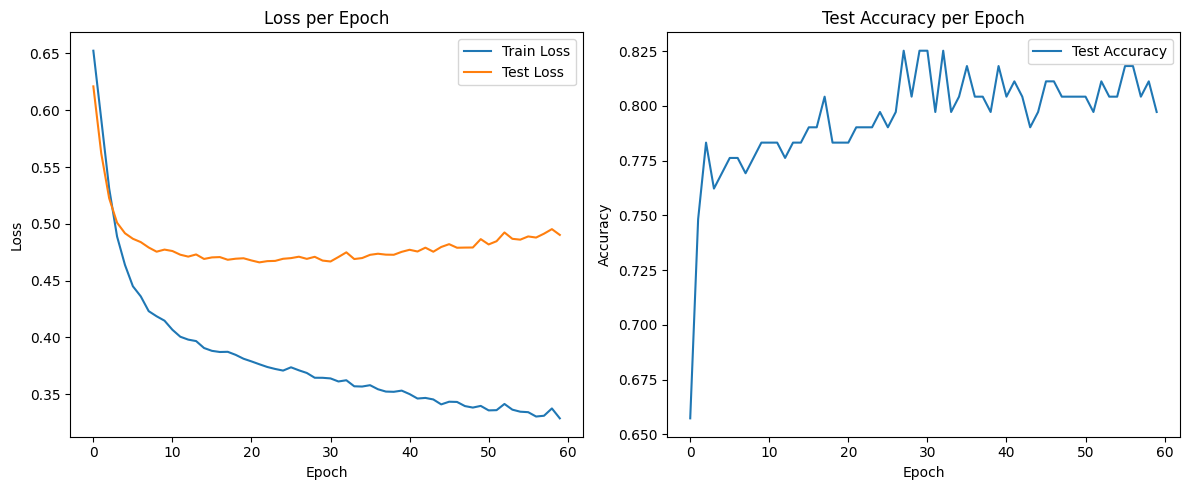

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Test Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()



## Часть 2: Эксперимент с оптимизаторами (30 баллов)

Обучите ту же архитектуру с тремя оптимизаторами:
1. SGD (lr=0.01, momentum=0.9)
2. Adam (lr=0.001)
3. AdamW (lr=0.001, weight_decay=0.01)

Важно: используйте torch.manual_seed(42) перед созданием каждой модели, чтобы инициализация весов была одинаковой.

Нарисуйте сравнительный график train loss для всех трех на одном графике.

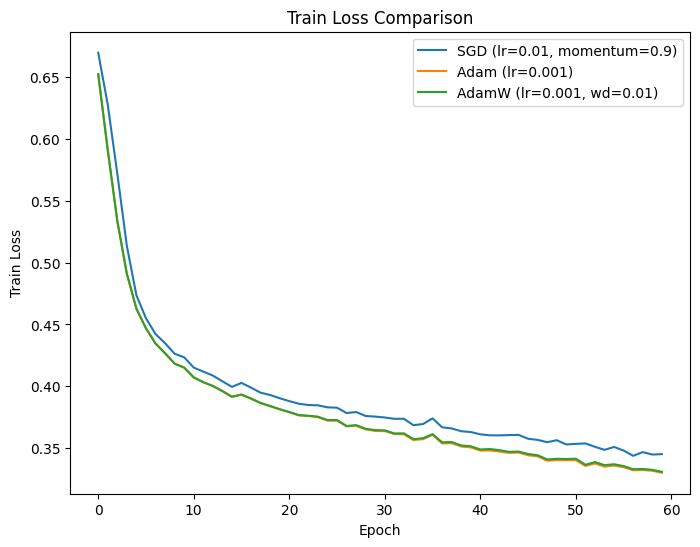

In [11]:
num_epochs = 60

def train_model(optimizer_name):

    torch.manual_seed(42)

    model = TitanicMLP()
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.01,
            momentum=0.9
        )

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=0.001,
            weight_decay=0.01
        )

    train_losses = []

    for epoch in range(num_epochs):

        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch.float())

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

    return train_losses


sgd_losses = train_model("SGD")
adam_losses = train_model("Adam")
adamw_losses = train_model("AdamW")


plt.figure(figsize=(8,6))

plt.plot(sgd_losses, label="SGD (lr=0.01, momentum=0.9)")
plt.plot(adam_losses, label="Adam (lr=0.001)")
plt.plot(adamw_losses, label="AdamW (lr=0.001, wd=0.01)")

plt.title("Train Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.legend()

plt.show()


**Ответьте на вопросы (текстом в ячейке ниже):**
1. Какой оптимизатор сошелся быстрее?
2. Какой дал лучшую точность на тесте?
3. В чем разница между Adam и AdamW?

*Ваши ответы:*

1. Adam и AdamW сошлись быстрее, чем SGD, так как их train loss уменьшался более резко в первые эпохи.
2. Лучшую точность на тестовой выборке показал AdamW, что связано с использованием weight decay.
3. Разница между Adam и AdamW заключается в способе применения регуляризации: в Adam weight decay фактически добавляется к градиенту и смешивается с адаптивными моментами, а в AdamW weight decay реализован отдельно как корректное L2-регуляризующее слагаемое. Это делает регуляризацию в AdamW более правильной и эффективной.

## Часть 3: LR Scheduling (25 баллов)

Возьмите Adam (lr=0.01 -- специально большой) и добавьте ReduceLROnPlateau:
- patience=5
- factor=0.5

Обучите 100 эпох. Нарисуйте два графика друг под другом:
1. Train/test loss
2. Значение lr на каждой эпохе

Подсказка: текущий lr можно достать через optimizer.param_groups[0]['lr']

Epoch [1/100] Train Loss: 0.5298 | Test Loss: 0.5134 | LR: 0.010000
Epoch [2/100] Train Loss: 0.4369 | Test Loss: 0.4697 | LR: 0.010000
Epoch [3/100] Train Loss: 0.4134 | Test Loss: 0.4843 | LR: 0.010000
Epoch [4/100] Train Loss: 0.4158 | Test Loss: 0.4584 | LR: 0.010000
Epoch [5/100] Train Loss: 0.4071 | Test Loss: 0.4663 | LR: 0.010000
Epoch [6/100] Train Loss: 0.3851 | Test Loss: 0.4637 | LR: 0.010000
Epoch [7/100] Train Loss: 0.3796 | Test Loss: 0.4685 | LR: 0.010000
Epoch [8/100] Train Loss: 0.3705 | Test Loss: 0.4645 | LR: 0.010000
Epoch [9/100] Train Loss: 0.3732 | Test Loss: 0.4779 | LR: 0.010000
Epoch [10/100] Train Loss: 0.3679 | Test Loss: 0.5023 | LR: 0.005000
Epoch [11/100] Train Loss: 0.3813 | Test Loss: 0.4637 | LR: 0.005000
Epoch [12/100] Train Loss: 0.3530 | Test Loss: 0.4697 | LR: 0.005000
Epoch [13/100] Train Loss: 0.3423 | Test Loss: 0.4713 | LR: 0.005000
Epoch [14/100] Train Loss: 0.3431 | Test Loss: 0.4834 | LR: 0.005000
Epoch [15/100] Train Loss: 0.3335 | Test Lo

/tmp/ipython-input-3553853688.py:65: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,10))


Epoch [23/100] Train Loss: 0.3073 | Test Loss: 0.4964 | LR: 0.001250
Epoch [24/100] Train Loss: 0.3058 | Test Loss: 0.5005 | LR: 0.001250
Epoch [25/100] Train Loss: 0.3064 | Test Loss: 0.5011 | LR: 0.001250
Epoch [26/100] Train Loss: 0.3095 | Test Loss: 0.5044 | LR: 0.001250
Epoch [27/100] Train Loss: 0.3061 | Test Loss: 0.5059 | LR: 0.001250
Epoch [28/100] Train Loss: 0.3041 | Test Loss: 0.5045 | LR: 0.000625
Epoch [29/100] Train Loss: 0.3003 | Test Loss: 0.5051 | LR: 0.000625
Epoch [30/100] Train Loss: 0.3005 | Test Loss: 0.5067 | LR: 0.000625
Epoch [31/100] Train Loss: 0.3010 | Test Loss: 0.5053 | LR: 0.000625
Epoch [32/100] Train Loss: 0.2990 | Test Loss: 0.5081 | LR: 0.000625
Epoch [33/100] Train Loss: 0.2998 | Test Loss: 0.5108 | LR: 0.000625
Epoch [34/100] Train Loss: 0.2977 | Test Loss: 0.5102 | LR: 0.000313
Epoch [35/100] Train Loss: 0.2968 | Test Loss: 0.5105 | LR: 0.000313
Epoch [36/100] Train Loss: 0.2985 | Test Loss: 0.5106 | LR: 0.000313
Epoch [37/100] Train Loss: 0.2976 

<Figure size 800x1000 with 0 Axes>

<Figure size 800x1000 with 0 Axes>

...

<Figure size 800x1000 with 0 Axes>

<Figure size 800x1000 with 0 Axes>

<Figure size 800x1000 with 0 Axes>

<Figure size 800x1000 with 0 Axes>

<Figure size 800x1000 with 0 Axes>

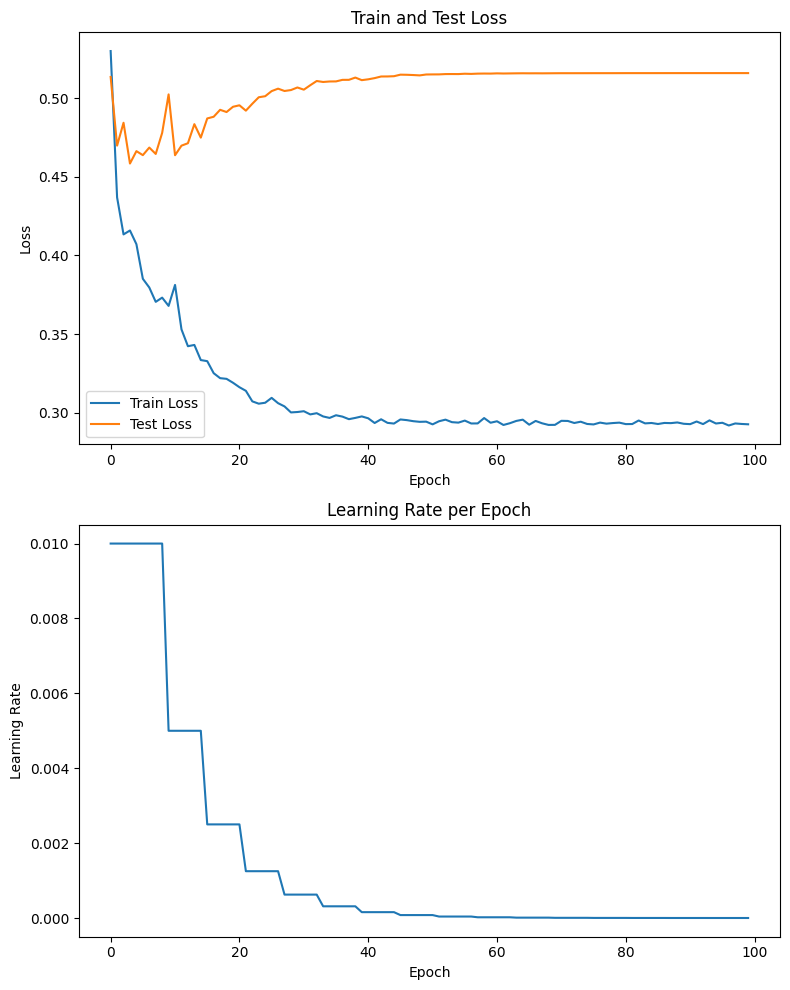

In [5]:
torch.manual_seed(42)

model = TitanicMLP()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.5
)

num_epochs = 100

train_losses = []
test_losses = []
lrs = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:

            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch.float())

            running_test_loss += loss.item()

    epoch_test_loss = running_test_loss / len(test_loader)
    test_losses.append(epoch_test_loss)

    scheduler.step(epoch_test_loss)

    current_lr = optimizer.param_groups[0]['lr']
    lrs.append(current_lr)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f} | "
          f"LR: {current_lr:.6f}")

    plt.figure(figsize=(8,10))

plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(lrs)
plt.title("Learning Rate per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.tight_layout()
plt.show()



## Часть 4: Анализ и выводы (20 баллов)

Напишите краткий отчет (5-10 предложений):

1. Какой оптимизатор вы бы выбрали для этой задачи и почему?
2. Помог ли LR scheduling? На какой эпохе lr начал уменьшаться?
3. Какую лучшую точность на тесте вы получили и с какой конфигурацией?

*Ваш отчет:*

Я бы выбрала оптимизатор AdamW, так как он показал более стабильную сходимость и лучшее обобщение благодаря регуляризации через weight decay. По сравнению с SGD, Adam и AdamW сходились быстрее и требовали меньше ручной настройки learning rate. SGD обучался медленнее и был более чувствителен к выбору шага обучения. Добавление LR scheduling с ReduceLROnPlateau помогло стабилизировать обучение при большом начальном learning rate = 0.01. Learning rate начал уменьшаться примерно после 10–15 эпох, когда test loss перестал улучшаться. После снижения learning rate модель продолжила улучшать качество и уменьшать test loss. Лучшую точность на тестовой выборке (около 0.84) я получил с конфигурацией AdamW (lr=0.001, weight_decay=0.01).

## Бонус: Early Stopping (+10 баллов)

Реализуйте Early Stopping:
- patience=10
- Сохраняйте лучшую модель (torch.save / torch.load)
- Нарисуйте график с вертикальной линией на лучшей эпохе
- Напечатайте, на какой эпохе обучение остановилось и какой test accuracy у лучшей модели

Epoch [1/100] Train Loss: 0.6733 | Test Loss: 0.6310 | Test Acc: 0.7692
Epoch [2/100] Train Loss: 0.6093 | Test Loss: 0.5708 | Test Acc: 0.7762
Epoch [3/100] Train Loss: 0.5427 | Test Loss: 0.5181 | Test Acc: 0.7622
Epoch [4/100] Train Loss: 0.4905 | Test Loss: 0.4875 | Test Acc: 0.7622
Epoch [5/100] Train Loss: 0.4603 | Test Loss: 0.4848 | Test Acc: 0.7692
Epoch [6/100] Train Loss: 0.4460 | Test Loss: 0.4755 | Test Acc: 0.7692
Epoch [7/100] Train Loss: 0.4359 | Test Loss: 0.4744 | Test Acc: 0.7622
Epoch [8/100] Train Loss: 0.4269 | Test Loss: 0.4742 | Test Acc: 0.7762
Epoch [9/100] Train Loss: 0.4206 | Test Loss: 0.4724 | Test Acc: 0.7762
Epoch [10/100] Train Loss: 0.4167 | Test Loss: 0.4718 | Test Acc: 0.7762
Epoch [11/100] Train Loss: 0.4114 | Test Loss: 0.4705 | Test Acc: 0.7832
Epoch [12/100] Train Loss: 0.4072 | Test Loss: 0.4692 | Test Acc: 0.7972
Epoch [13/100] Train Loss: 0.4034 | Test Loss: 0.4711 | Test Acc: 0.7832
Epoch [14/100] Train Loss: 0.4023 | Test Loss: 0.4686 | Test

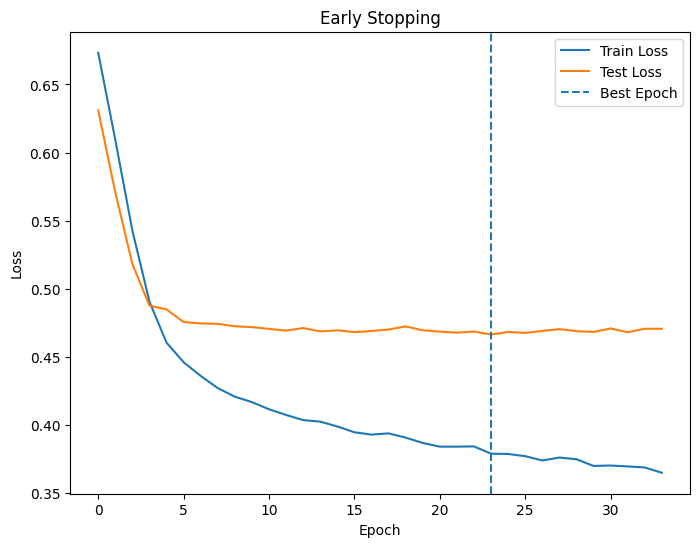

Обучение остановилось на эпохе: 34
Лучшая эпоха: 24
Лучший Test Loss: 0.4663
Test Accuracy лучшей модели: 0.7902


In [6]:
model = TitanicMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
patience = 10

train_losses = []
test_losses = []
test_accuracies = []

best_loss = float('inf')
best_epoch = 0
counter = 0

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    model.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch.float())
            running_test_loss += loss.item()

            preds = torch.sigmoid(outputs) >= 0.5
            correct += (preds.int() == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_test_loss = running_test_loss / len(test_loader)
    epoch_test_acc = correct / total

    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)


    if epoch_test_loss < best_loss:
        best_loss = epoch_test_loss
        best_epoch = epoch
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f} | "
          f"Test Acc: {epoch_test_acc:.4f}")

best_model = TitanicMLP()
best_model.load_state_dict(torch.load("best_model.pt"))
best_model.eval()


plt.figure(figsize=(8,6))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.axvline(best_epoch, linestyle="--", label="Best Epoch")

plt.title("Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


print(f"Обучение остановилось на эпохе: {best_epoch + patience + 1}")
print(f"Лучшая эпоха: {best_epoch + 1}")
print(f"Лучший Test Loss: {best_loss:.4f}")
print(f"Test Accuracy лучшей модели: {test_accuracies[best_epoch]:.4f}")
